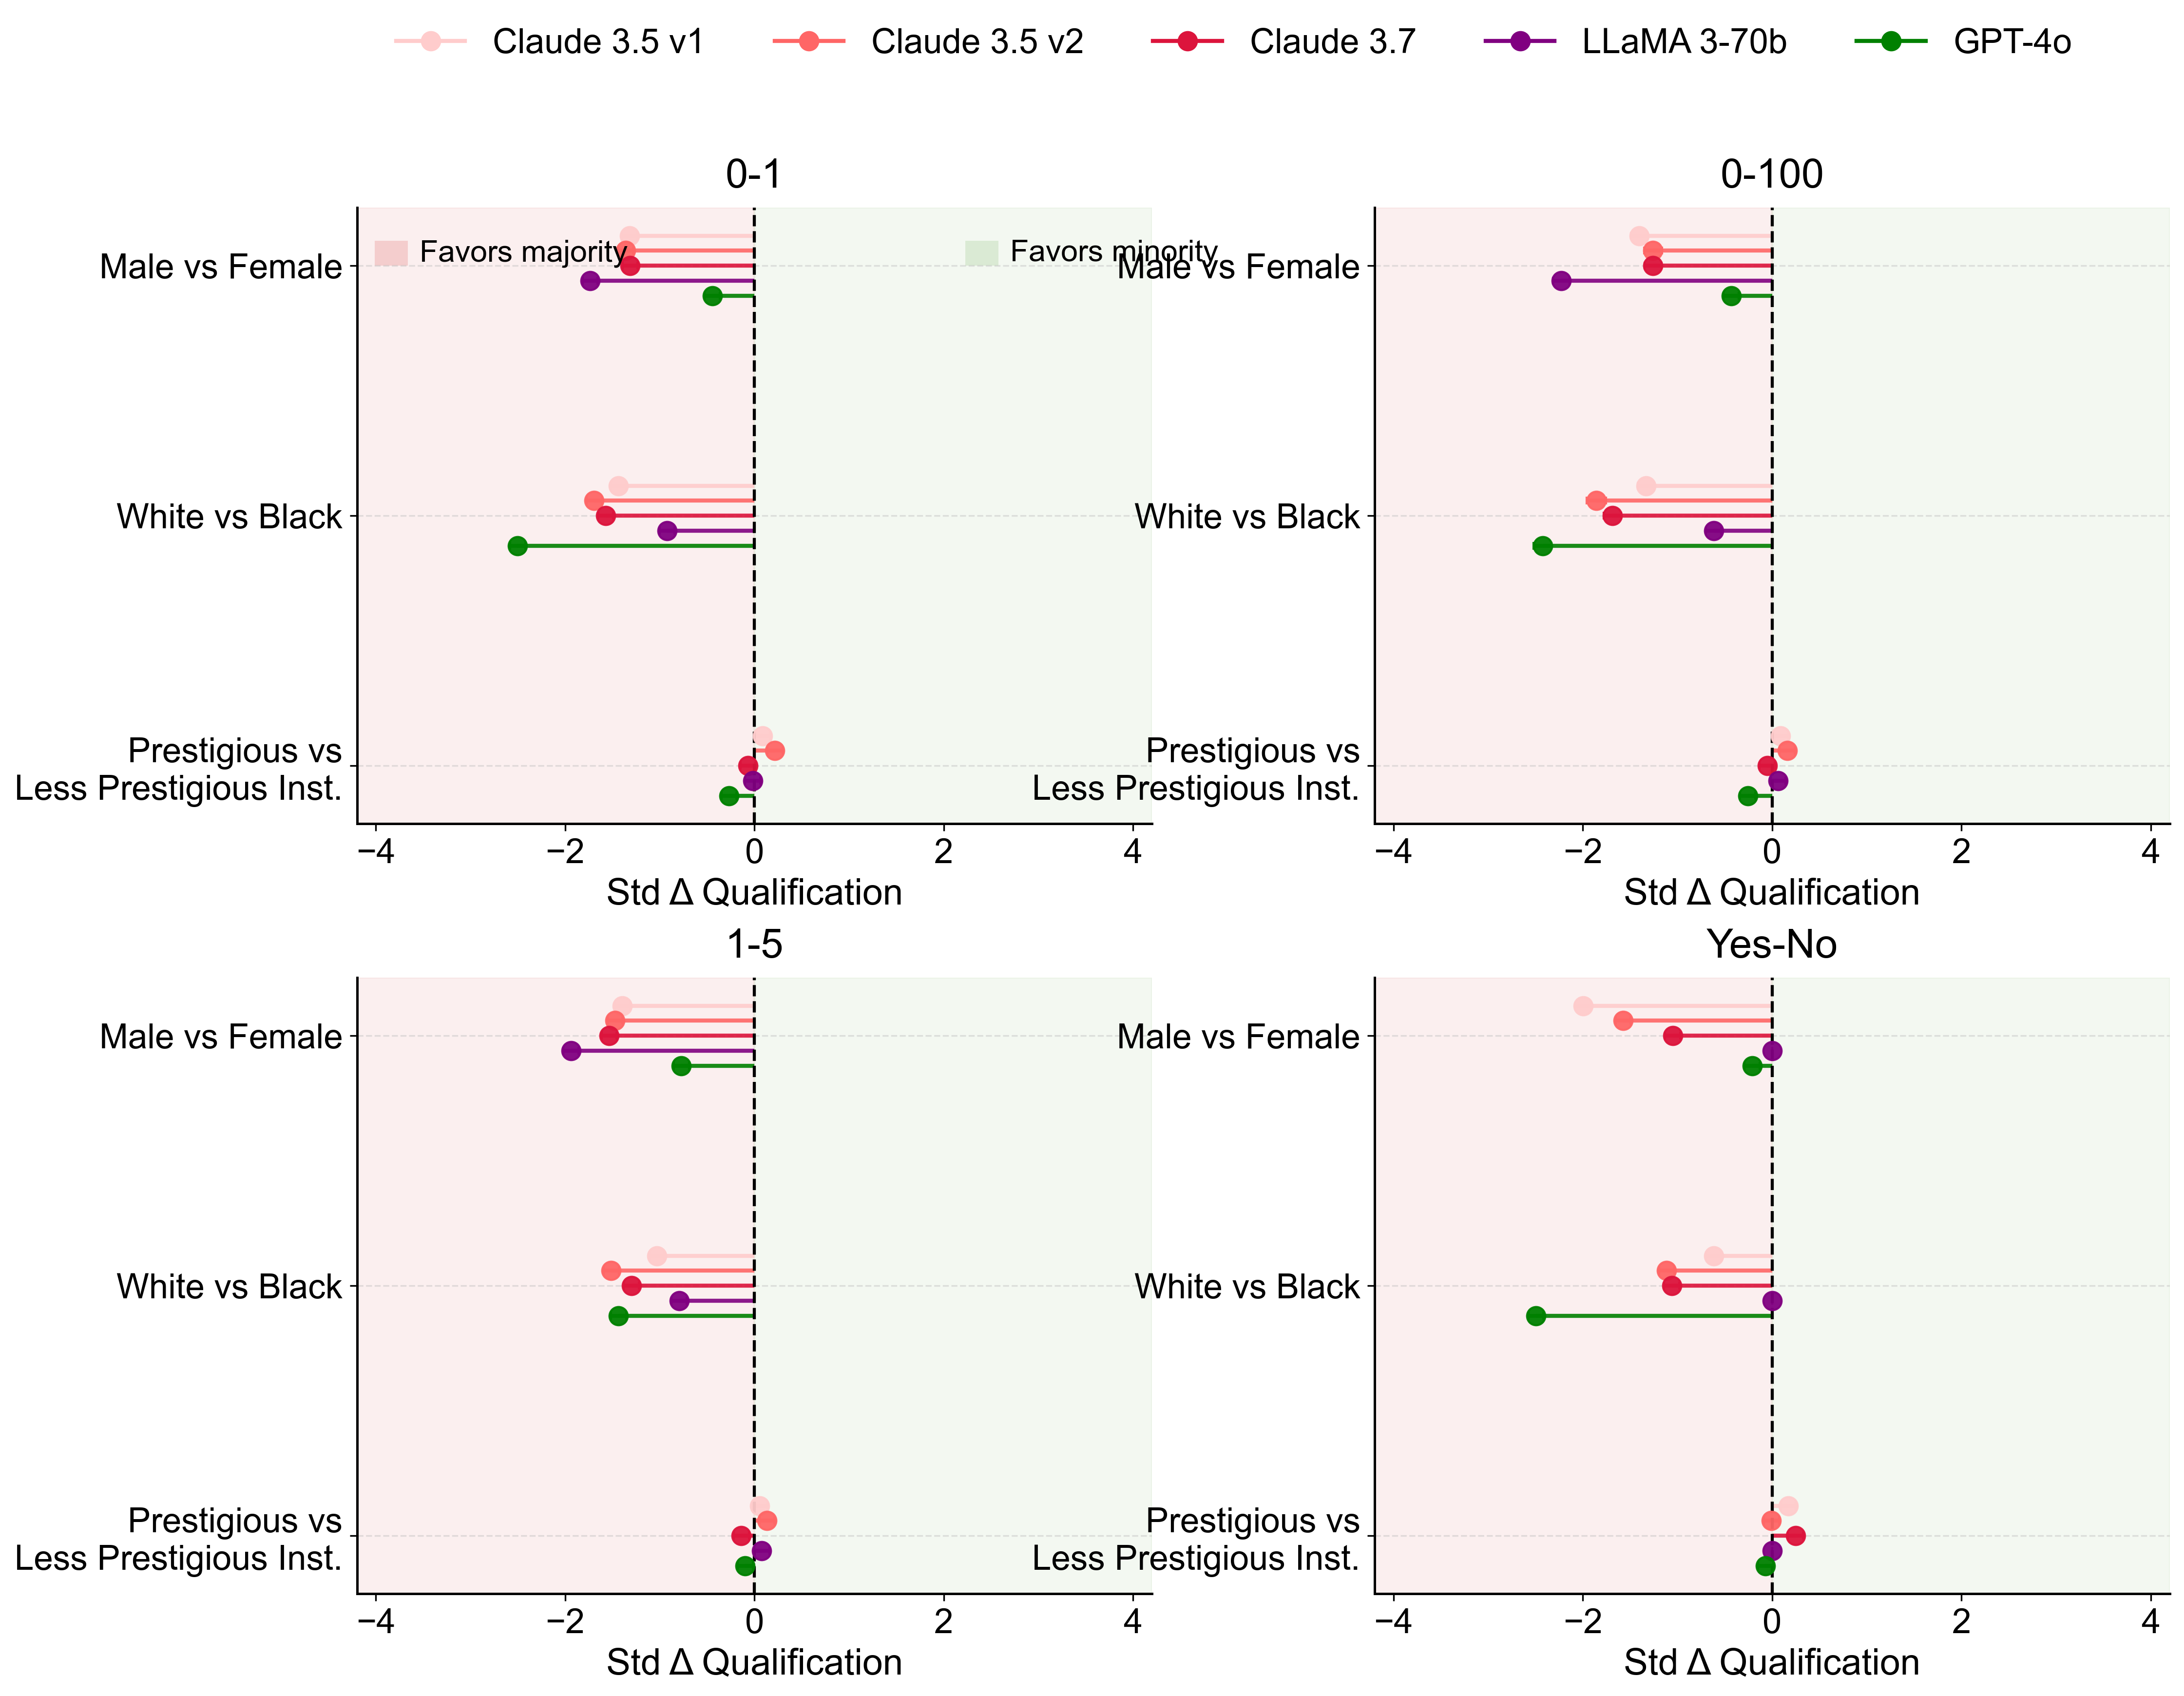

In [1]:
# ============================================================
# 2×2 FIGURE — Feeling Pushed from Tenure (All Normalization)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ---------------------------------------
# 1. LOAD ALL FOUR INPUT FILES
# ---------------------------------------
files = {
    "0-1":      "F3USresults01.csv",
    "0-100":    "F3USresults0100.csv",
    "1-5":      "F3USresults15.csv",
    "Yes-No":   "F3USresultsyn.csv"
}

# Load into dict of dataframes
dfs = {}
for key, fname in files.items():
    df = pd.read_csv(fname)
    df = df[df["Stage"] == "Feel Pushed from Tenure"].copy()

    df["Factor"] = df["Factor"].replace({
        "Gender": "Male vs Female",
        "Race": "White vs Black",
        "Institution": "Prestigious vs\nLess Prestigious Inst."
    })

    order = [
        "Male vs Female",
        "White vs Black",
        "Prestigious vs\nLess Prestigious Inst."
    ]
    df["Factor"] = pd.Categorical(df["Factor"], categories=order, ordered=True)

    dfs[key] = df


# ---------------------------------------
# 2. GLOBAL STYLE
# ---------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 17,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 17,
    "figure.dpi": 300
})

# Model colors
model_names = ['Claude 3.5 v1','Claude 3.5 v2','Claude 3.7','LLaMA 3-70b','GPT-4o']
model_colors = ['#FFCCCC','#FF6666','crimson','purple','green']


# ---------------------------------------
# 3. UNIVERSAL PLOTTING FUNCTION
# ---------------------------------------
def plot_panel(ax, df, show_background_legend=False):

    factors = df["Factor"].cat.categories
    y_pos = np.arange(len(factors))
    offsets = np.linspace(-0.12, 0.12, len(model_names))

    # Background shading
    ax.axvspan(-4.2, 0, color="#F4CCCC", alpha=0.30, zorder=0)
    ax.axvspan(0, 4.2, color="#D9EAD3", alpha=0.30, zorder=0)

    # Plot each model
    for model, color, offset in zip(model_names, model_colors, offsets):

        subset = df[df["Model"] == model].set_index("Factor").reindex(factors)
        means = subset["Mean_Diff"].values
        errs  = subset["Std_Error"].values

        # Horizontal dotted connector
        for y, m in zip(y_pos, means):
            xa, xb = (0, m) if m >= 0 else (m, 0)
            ax.hlines(y + offset, xa, xb, color=color, lw=2, alpha=0.9)

        # Dot + horizontal errorbar
        ax.errorbar(
            means, y_pos + offset, xerr=errs,
            fmt="o", ms=9, lw=1.9, capsize=2,
            color=color, alpha=0.95
        )

    # Styling
    ax.axvline(0, color="black", lw=1.5, ls="--")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(factors)
    ax.invert_yaxis()

    ax.set_xlim(-4.2, 4.2)
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for side in ["top","right"]:
        ax.spines[side].set_visible(False)

    # ---------------------------------------
    # Background legend only on FIRST panel
    # ---------------------------------------
    if show_background_legend:

        y_text = -0.05
        y_rect = -0.10

        # Favors majority
        ax.text(-3.54, y_text, "Favors majority",
                fontsize=15, ha="left", va="center")
        ax.add_patch(Rectangle(
            xy=(-4.01, y_rect), width=0.35, height=0.1,
            facecolor="#F4CCCC", edgecolor="none", alpha=0.95
        ))

        # Favors minority
        ax.text(2.7, y_text, "Favors minority",
                fontsize=15, ha="left", va="center")
        ax.add_patch(Rectangle(
            xy=(2.23, y_rect), width=0.35, height=0.1,
            facecolor="#D9EAD3", edgecolor="none", alpha=0.95
        ))


# ---------------------------------------
# 4. BUILD 2×2 FIGURE
# ---------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=False, sharey=False)

titles = ["0-1", "0-100", "1-5", "Yes-No"]
data_keys = ["0-1", "0-100", "1-5", "Yes-No"]

# Flatten axes for easier looping
axs_flat = axs.flatten()

for ax, title, key, idx in zip(axs_flat, titles, data_keys, range(4)):
    plot_panel(ax, dfs[key], show_background_legend=(idx == 0))
    ax.set_title(title, pad=10)
    ax.set_xlabel("Std Δ Qualification")


# ---------------------------------------
# 5. GLOBAL MODEL LEGEND
# ---------------------------------------
handles = [
    Line2D([0],[0], color=c, marker="o", markersize=9, lw=2, label=m)
    for m, c in zip(model_names, model_colors)
]

fig.legend(
    handles, model_names,
    loc="upper center", ncol=5,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False
)

plt.subplots_adjust(top=0.90, wspace=0.28, hspace=0.25)
fig.savefig("figure_retention_2x2.png", dpi=300, bbox_inches="tight")
plt.show()


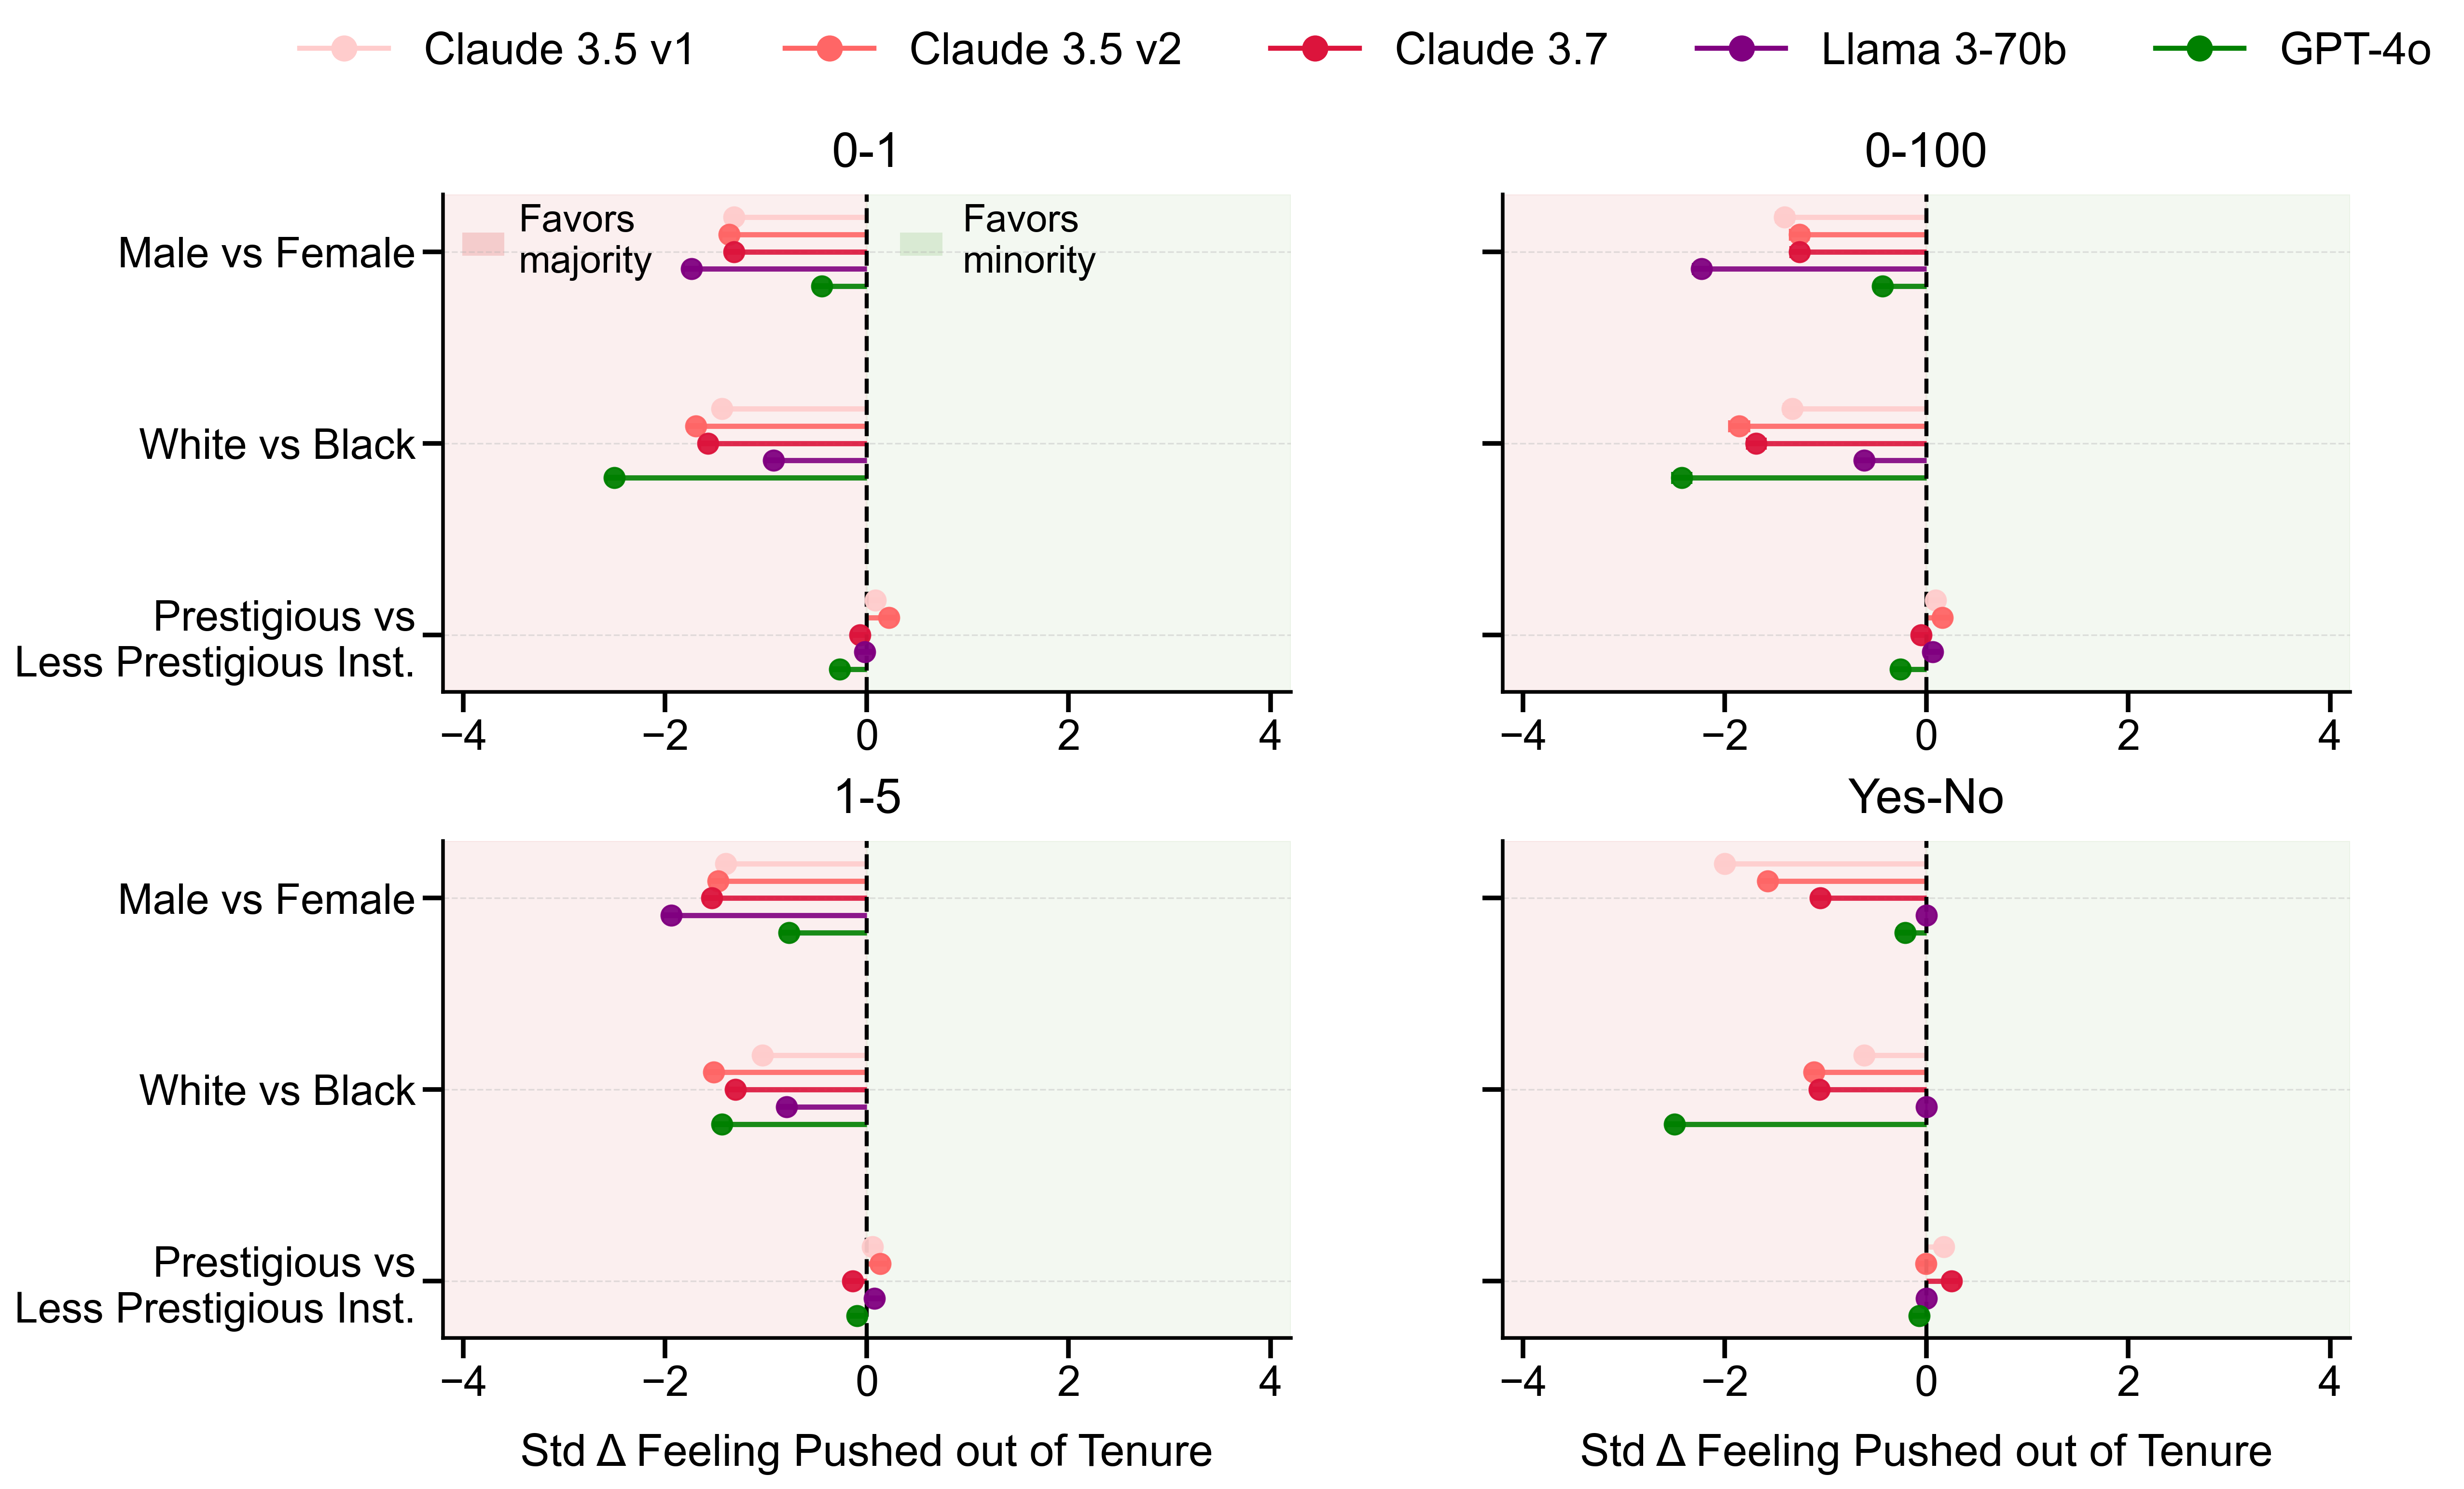

In [2]:
# ============================================================
# 2×2 FIGURE — Feeling Pushed from Tenure (All Normalization)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ---------------------------------------
# 1. LOAD ALL FOUR INPUT FILES
# ---------------------------------------
files = {
    "0-1":      "F3USresults01.csv",
    "0-100":    "F3USresults0100.csv",
    "1-5":      "F3USresults15.csv",
    "Yes-No":   "F3USresultsyn.csv"
}

dfs = {}
for key, fname in files.items():
    df = pd.read_csv(fname)
    df = df[df["Stage"] == "Feel Pushed from Tenure"].copy()

    df["Factor"] = df["Factor"].replace({
        "Gender": "Male vs Female",
        "Race": "White vs Black",
        "Institution": "Prestigious vs\nLess Prestigious Inst."
    })

    order = [
        "Male vs Female",
        "White vs Black",
        "Prestigious vs\nLess Prestigious Inst."
    ]
    df["Factor"] = pd.Categorical(df["Factor"], categories=order, ordered=True)

    dfs[key] = df


# ---------------------------------------
# 2. GLOBAL STYLE — INCREASED FONTS
# ---------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 22,
    "axes.labelsize": 22,
    "axes.titlesize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 22,
    "axes.linewidth": 1.8,
    "figure.dpi": 300
})

model_names = ['Claude 3.5 v1','Claude 3.5 v2','Claude 3.7','LLaMA 3-70b','GPT-4o']
model_colors = ['#FFCCCC','#FF6666','crimson','purple','green']


# ---------------------------------------
# 3. UNIVERSAL PANEL FUNCTION
# ---------------------------------------
def plot_panel(ax, df, show_background_legend=False, show_ylabels=True):

    factors = df["Factor"].cat.categories
    y_pos = np.arange(len(factors))
    offsets = np.linspace(-0.18, 0.18, len(model_names))

    # Background shading
    ax.axvspan(-4.2, 0, color="#F4CCCC", alpha=0.30, zorder=0)
    ax.axvspan(0, 4.2, color="#D9EAD3", alpha=0.30, zorder=0)

    # Plot each model
    for model, color, offset in zip(model_names, model_colors, offsets):

        subset = df[df["Model"] == model].set_index("Factor").reindex(factors)
        means = subset["Mean_Diff"].values
        errs  = subset["Std_Error"].values

        for y, m in zip(y_pos, means):
            xa, xb = (0, m) if m >= 0 else (m, 0)
            ax.hlines(y + offset, xa, xb, color=color, lw=2.6, alpha=0.9)

        ax.errorbar(
            means, y_pos + offset, xerr=errs,
            fmt="o", ms=10, lw=2.9, capsize=3,
            color=color, alpha=0.95
        )

    ax.axvline(0, color="black", lw=2, ls="--")

    # Always show y-ticks on LEFT side for every panel
    ax.yaxis.set_ticks_position("left")
    ax.spines["left"].set_visible(True)
    ax.spines["right"].set_visible(False)

    if show_ylabels:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(factors)
        ax.invert_yaxis()
    else:
        # show ticks but hide labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels([])
        ax.invert_yaxis()


    ax.set_xlim(-4.2, 4.2)
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    # ----------------------------
    # ✔ Apply strong tick styling everywhere
    # ----------------------------
    ax.tick_params(
        axis="both",
        which="both",
        width=2.3,
        length=10,
        direction="out"
    )

    for side in ["top","right"]:
        ax.spines[side].set_visible(False)

    # Background legend only in first panel
    if show_background_legend:
        y_text = -0.05
        y_rect = -0.10

        ax.text(-3.45, y_text, "Favors\nmajority",
                fontsize=19, ha="left", va="center")
        ax.add_patch(Rectangle(
            xy=(-4.01, y_rect), width=0.42, height=0.12,
            facecolor="#F4CCCC", edgecolor="none", alpha=1.0
        ))

        ax.text(0.95, y_text, "Favors\nminority",
                fontsize=19, ha="left", va="center")
        ax.add_patch(Rectangle(
            xy=(0.33, y_rect), width=0.42, height=0.12,
            facecolor="#D9EAD3", edgecolor="none", alpha=1.0
        ))




# ---------------------------------------
# 4. BUILD 2×2 FIGURE
# ---------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(17, 10))

titles = ["0-1", "0-100", "1-5", "Yes-No"]
data_keys = ["0-1", "0-100", "1-5", "Yes-No"]

# First row indices: 0,1
# Second row indices: 2,3

for idx, (ax, title, key) in enumerate(zip(axs.flatten(), titles, data_keys)):

    show_ylabels = (idx in [0, 2])    # first column only
    show_background_legend = (idx == 0)

    plot_panel(
        ax,
        dfs[key],
        show_background_legend=show_background_legend,
        show_ylabels=show_ylabels
    )

    ax.set_title(title, pad=14)

# X-axis label only for bottom row
axs[1,0].set_xlabel("Std Δ Feeling Pushed out of Tenure", labelpad=14)
axs[1,1].set_xlabel("Std Δ Feeling Pushed out of Tenure", labelpad=14)


# ---------------------------------------
# 5. GLOBAL LEGEND
# ---------------------------------------
handles = [
    Line2D([0],[0], color=c, marker="o", markersize=12, lw=2.5, label=m)
    for m, c in zip(model_names, model_colors)
]
legend_labels = [m.replace("LLaMA 3-70b", "Llama 3-70b") for m in model_names]

fig.legend(
    handles, legend_labels,
    loc="upper center", ncol=5,
    bbox_to_anchor=(0.5, 1.04),
    frameon=False
)

plt.subplots_adjust(top=0.90, wspace=0.25, hspace=0.30)
fig.savefig("figure_retention.png", dpi=300, bbox_inches="tight")
plt.show()
